Original dataset:
   Index  Dim1  Dim2  Dim3  Dim4
0      0 -0.48  0.27 -0.86  0.86
1      1  0.48  0.22  0.05  0.34
2      2  0.09 -0.25  0.65  0.48
3      3 -0.10 -0.35 -0.91  0.39
4      4  0.96  0.13  0.42  0.70
5      5  0.82  0.44 -0.78 -0.31
6      6 -0.06 -0.28 -0.27  0.92

Original numeric vectors:
[[-0.48  0.27 -0.86  0.86]
 [ 0.48  0.22  0.05  0.34]
 [ 0.09 -0.25  0.65  0.48]
 [-0.1  -0.35 -0.91  0.39]
 [ 0.96  0.13  0.42  0.7 ]
 [ 0.82  0.44 -0.78 -0.31]
 [-0.06 -0.28 -0.27  0.92]]

Normalized vectors:
[[-0.35952283  0.20223159 -0.64414506  0.64414506]
 [ 0.76190476  0.34920635  0.07936508  0.53968254]
 [ 0.10580915 -0.29391432  0.76417722  0.56431549]
 [-0.09480057 -0.331802   -0.8626852   0.36972223]
 [ 0.75778716  0.10261701  0.33153188  0.55255314]
 [ 0.65432706  0.35110233 -0.62240867 -0.24736755]
 [-0.05996104 -0.27981818 -0.26982467  0.91940258]]

Binary vectors:
[[0 1 0 1]
 [1 1 1 1]
 [1 0 1 1]
 [0 0 0 1]
 [1 1 1 1]
 [1 1 0 0]
 [0 0 0 1]]

Binary table:
   Index  Bi

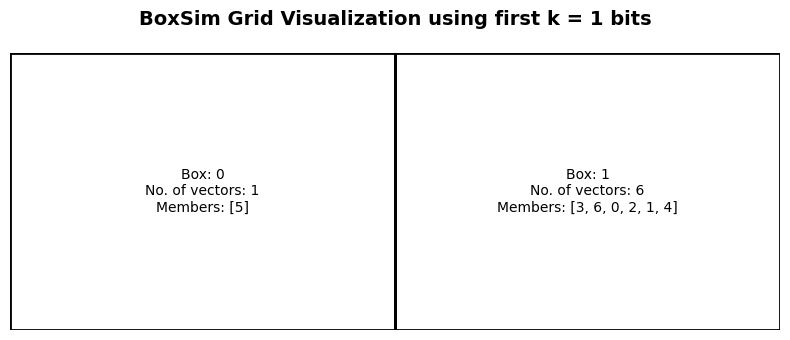

RESULTS FOR k = 2
Rows with assigned boxes:
   Index  Bit4  Bit3  Bit2  Bit1 Box
0      5     0     0     1     1  00
1      3     1     0     0     0  10
2      6     1     0     0     0  10
3      0     1     0     1     0  10
4      2     1     1     0     1  11
5      1     1     1     1     1  11
6      4     1     1     1     1  11

Box summary:
  Box    Members  Count
0  00        [5]      1
1  10  [3, 6, 0]      3
2  11  [2, 1, 4]      3



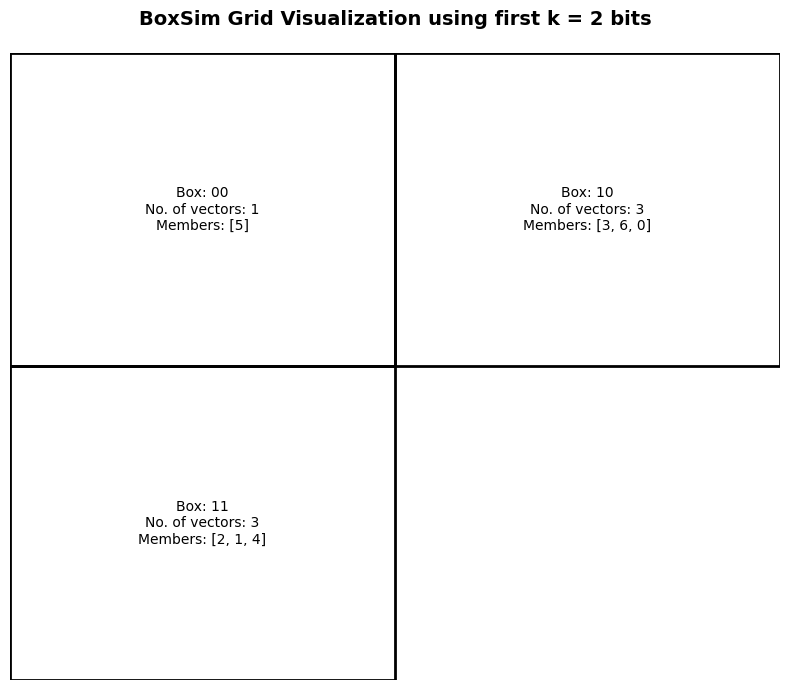

RESULTS FOR k = 3
Rows with assigned boxes:
   Index  Bit4  Bit3  Bit2  Bit1  Box
0      5     0     0     1     1  001
1      3     1     0     0     0  100
2      6     1     0     0     0  100
3      0     1     0     1     0  101
4      2     1     1     0     1  110
5      1     1     1     1     1  111
6      4     1     1     1     1  111

Box summary:
   Box Members  Count
0  001     [5]      1
1  100  [3, 6]      2
2  101     [0]      1
3  110     [2]      1
4  111  [1, 4]      2



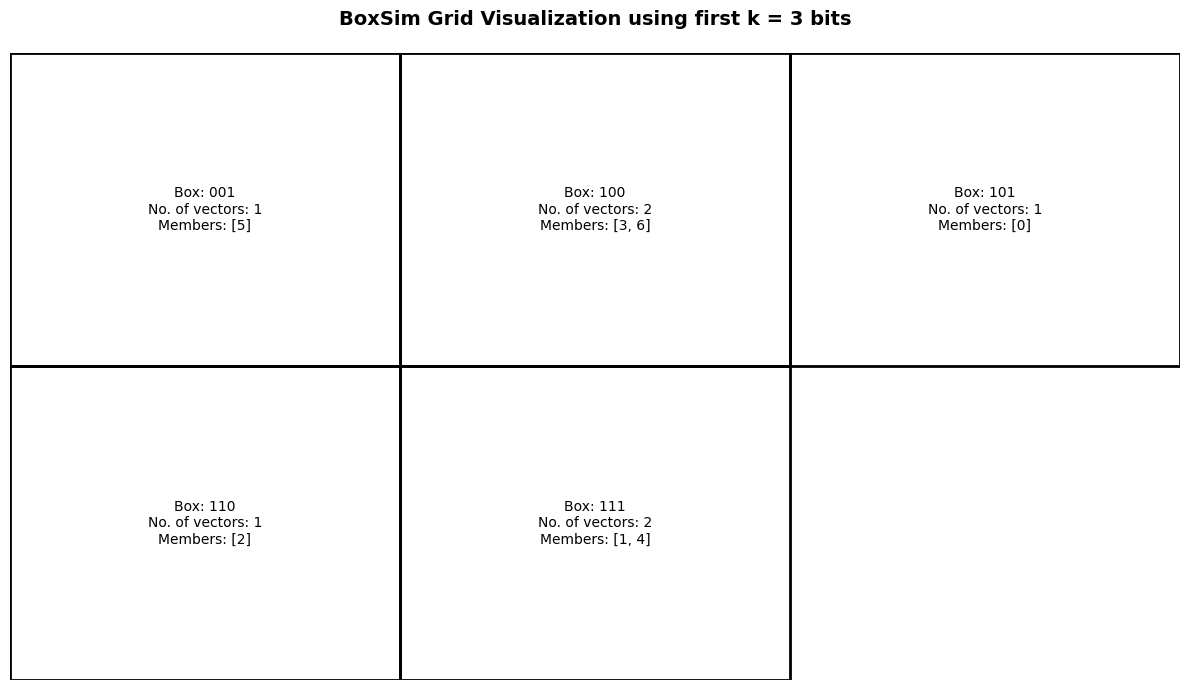

RESULTS FOR k = 4
Rows with assigned boxes:
   Index  Bit4  Bit3  Bit2  Bit1   Box
0      5     0     0     1     1  0011
1      3     1     0     0     0  1000
2      6     1     0     0     0  1000
3      0     1     0     1     0  1010
4      2     1     1     0     1  1101
5      1     1     1     1     1  1111
6      4     1     1     1     1  1111

Box summary:
    Box Members  Count
0  0011     [5]      1
1  1000  [3, 6]      2
2  1010     [0]      1
3  1101     [2]      1
4  1111  [1, 4]      2



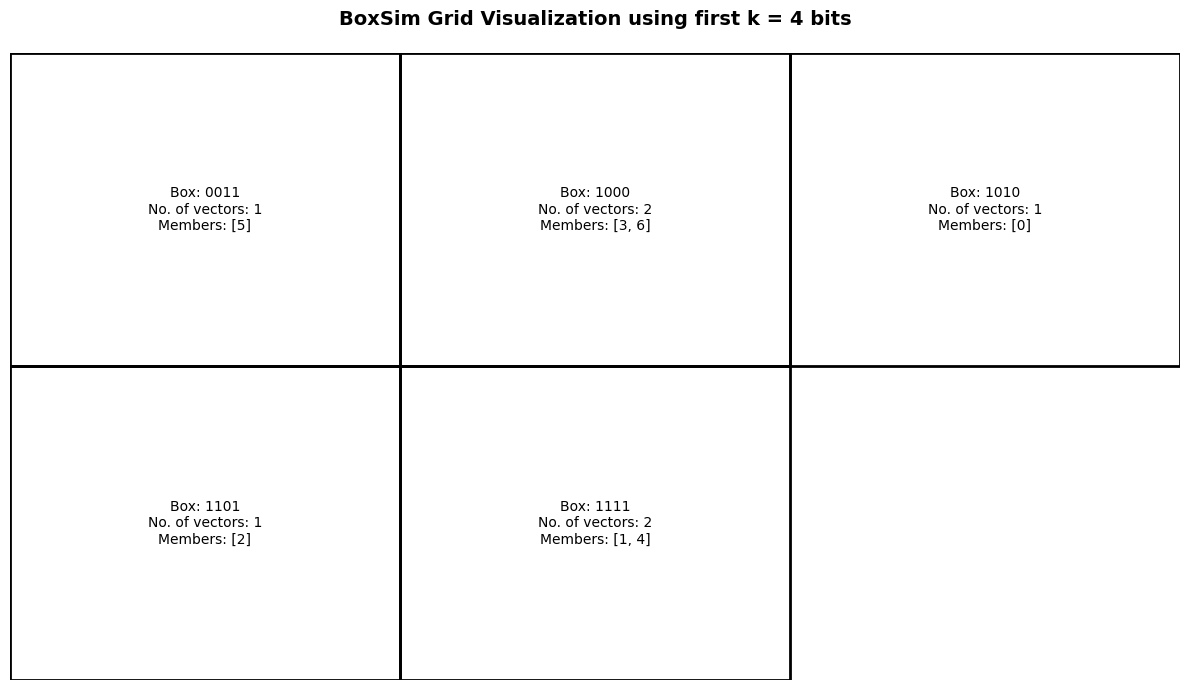

Unique full binary patterns:
  BinaryCode Members  Count
0       0011     [5]      1
1       1000  [3, 6]      2
2       1010     [0]      1
3       1101     [2]      1
4       1111  [1, 4]      2



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import math

# =========================================================
# 1) LOAD THE SAMPLE DATASET
# =========================================================
# The file is whitespace-separated.
# Column 0 = vector/index id
# Remaining columns = numeric dimensions of each vector

df = pd.read_csv("data6.txt", sep=r"\s+", header=None)

# Rename columns so the dataset is easier to read
df.columns = ["Index", "Dim1", "Dim2", "Dim3", "Dim4"]

print("Original dataset:")
print(df)
print()


# =========================================================
# 2) EXTRACT ONLY THE NUMERIC VECTOR VALUES
# =========================================================
# We do not use the Index column in the mathematical steps
# because it is only an identifier.

X = df[["Dim1", "Dim2", "Dim3", "Dim4"]].values

print("Original numeric vectors:")
print(X)
print()


# =========================================================
# 3) NORMALIZE EACH VECTOR
# =========================================================
# Each row vector is converted to unit length.
# This removes the effect of magnitude and keeps direction.
#
# Formula:
# normalized_vector = vector / ||vector||
#
# If norm = 0, we skip division to avoid errors.

norms = np.linalg.norm(X, axis=1, keepdims=True)
X_normalized = np.divide(X, norms, where=(norms != 0))

print("Normalized vectors:")
print(X_normalized)
print()


# =========================================================
# 4) CONVERT EACH VECTOR INTO A BINARY VECTOR
# =========================================================
# Rule:
# if value > 0  -> 1
# if value <= 0 -> 0
#
# This converts each continuous vector into a binary code.

X_binary = (X_normalized > 0).astype(int)

print("Binary vectors:")
print(X_binary)
print()


# =========================================================
# 5) BUILD A BINARY DATAFRAME
# =========================================================
# This makes the binary representation easy to display.

binary_df = pd.DataFrame(X_binary, columns=["Bit1", "Bit2", "Bit3", "Bit4"])
binary_df.insert(0, "Index", df["Index"])

print("Binary table:")
print(binary_df)
print()


# =========================================================
# 6) COMPUTE VARIANCE OF EACH BIT COLUMN
# =========================================================
# We use np.var(..., axis=0) to compute variance column-wise.
#
# In this algorithm:
# lower variance = more useful column
# higher variance = less useful column
#
# Since values are only 0 and 1, a low-variance column means
# the column is more stable / less mixed.

bit_matrix = binary_df[["Bit1", "Bit2", "Bit3", "Bit4"]].values
column_variances = np.var(bit_matrix, axis=0)

usefulness_df = pd.DataFrame({
    "Column": ["Bit1", "Bit2", "Bit3", "Bit4"],
    "Variance": column_variances
}).sort_values(by="Variance", ascending=True).reset_index(drop=True)

print("Column usefulness based on variance:")
print(usefulness_df)
print()


# =========================================================
# 7) REORDER COLUMNS BY USEFULNESS
# =========================================================
# The most useful bit columns come first.
# This reordered order is used for sorting and grouping.

sorted_bit_columns = usefulness_df["Column"].tolist()

reordered_binary_df = binary_df[["Index"] + sorted_bit_columns].copy()

print("Binary table after reordering columns:")
print(reordered_binary_df)
print()


# =========================================================
# 8) SORT ROWS USING THE REORDERED BIT COLUMNS
# =========================================================
# Rows with similar binary prefixes are brought together.

sorted_rows_df = reordered_binary_df.sort_values(by=sorted_bit_columns).reset_index(drop=True)

# Also create a full binary string for readability
sorted_rows_df["BinaryCode"] = sorted_rows_df[sorted_bit_columns].astype(str).agg("".join, axis=1)

print("Sorted rows with binary code:")
print(sorted_rows_df)
print()


# =========================================================
# 9) FUNCTION TO FORM BOXES USING FIRST k BITS
# =========================================================
# If two rows have the same first k bits, they go into the
# same box/cluster.

def make_boxes(sorted_df, bit_cols, k):
    # Take the first k bit columns
    first_k_cols = bit_cols[:k]

    # Create box label by joining the first k bits
    # Example: [1,0,1] becomes "101"
    grouped_df = sorted_df.copy()
    grouped_df["Box"] = grouped_df[first_k_cols].astype(str).agg("".join, axis=1)

    # Group rows by box and collect their vector indices
    box_summary = (
        grouped_df.groupby("Box")["Index"]
        .apply(list)
        .reset_index(name="Members")
    )

    # Count how many vectors belong to each box
    box_summary["Count"] = box_summary["Members"].apply(len)

    # Sort for neat display
    box_summary = box_summary.sort_values(by="Box").reset_index(drop=True)

    return grouped_df, box_summary


# =========================================================
# 10) FUNCTION TO DRAW BOXES AS A GRID
# =========================================================
# Each grid cell = one box
# Inside each cell we show:
# - box label
# - number of vectors
# - vector ids in that box

def draw_box_grid(box_summary, k):
    num_boxes = len(box_summary)

    # Choose number of columns and rows so grid looks balanced
    cols = math.ceil(math.sqrt(num_boxes))
    rows = math.ceil(num_boxes / cols)

    # Make figure size depend on grid size
    fig, ax = plt.subplots(figsize=(cols * 4, rows * 3.5))

    # Set plotting area to grid dimensions
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.axis("off")

    # Add title
    ax.set_title(f"BoxSim Grid Visualization using first k = {k} bits",
                 fontsize=14, fontweight="bold", pad=20)

    for i, row in box_summary.iterrows():
        # Determine row and column position of the current box
        grid_row = i // cols
        grid_col = i % cols

        # Convert to plotting coordinates
        x = grid_col
        y = rows - grid_row - 1

        # Draw rectangle for this box
        rect = Rectangle((x, y), 1, 1, fill=False, linewidth=2)
        ax.add_patch(rect)

        # Extract box details
        box_label = row["Box"]
        count = row["Count"]
        members = row["Members"]

        # Create text to display inside the rectangle
        text = f"Box: {box_label}\nNo. of vectors: {count}\nMembers: {members}"

        # Put text in center of box
        ax.text(
            x + 0.5,
            y + 0.5,
            text,
            ha="center",
            va="center",
            fontsize=10,
            wrap=True
        )

    plt.tight_layout()
    plt.show()


# =========================================================
# 11) RUN THE ALGORITHM FOR DIFFERENT k VALUES
# =========================================================
# Since there are 4 bit columns, possible k values are 1, 2, 3, 4
#
# Small k -> fewer, larger boxes
# Large k -> more, smaller boxes

for k in range(1, len(sorted_bit_columns) + 1):
    print("=" * 50)
    print(f"RESULTS FOR k = {k}")
    print("=" * 50)

    # Form boxes using first k bits
    grouped_rows, box_summary = make_boxes(sorted_rows_df, sorted_bit_columns, k)

    # Show row-level assignments
    print("Rows with assigned boxes:")
    print(grouped_rows[["Index"] + sorted_bit_columns + ["Box"]])
    print()

    # Show summary of boxes
    print("Box summary:")
    print(box_summary)
    print()

    # Draw the grid-style box visualization
    draw_box_grid(box_summary, k)


# =========================================================
# 12) OPTIONAL: SHOW UNIQUE FULL BINARY PATTERNS
# =========================================================
# This shows exact duplicates of the full binary code,
# not just grouping by first k bits.

unique_patterns = (
    sorted_rows_df.groupby("BinaryCode")["Index"]
    .apply(list)
    .reset_index(name="Members")
)

unique_patterns["Count"] = unique_patterns["Members"].apply(len)

print("Unique full binary patterns:")
print(unique_patterns)
print()

The code implements the BoxSim clustering process on a small dataset step by step. First, it loads the dataset from data6.txt, where the first column represents the vector ID and the remaining columns represent the numerical dimensions of each vector. The numeric vectors are then extracted and normalized so that each vector has unit length, which removes the effect of magnitude and keeps only the direction of the vector. Next, every value in the normalized vectors is converted into a binary value using a threshold rule: values greater than zero become 1, and values less than or equal to zero become 0, producing a binary representation of each vector. After that, the algorithm calculates the variance of each binary column using NumPy’s np.var() function to determine which columns are more stable; columns with lower variance are considered more useful. The binary columns are then reordered from lowest variance to highest variance, and the rows are sorted according to this new bit order so that vectors with similar binary prefixes appear close together. The algorithm then forms boxes (clusters) by selecting the first k bits of each binary code; vectors with the same first k bits are grouped into the same box. A summary is created showing each box label, the vector IDs inside it, and the number of vectors in that box. Finally, the boxes are displayed visually as a grid, where each cell represents one box and contains the box label, the number of vectors, and the list of vector indices belonging to that box.

In the original BoxSim implementation we used variance of the binary columns to rank the bits and then formed boxes using the first k bits. If we replace that step with Hamming distance, should the Hamming distance be used to compare the binary vectors (rows) and group vectors whose distance is below a threshold into the same box, or should it somehow be used to evaluate or rank the bit columns before forming the boxes?

iris mnist subset

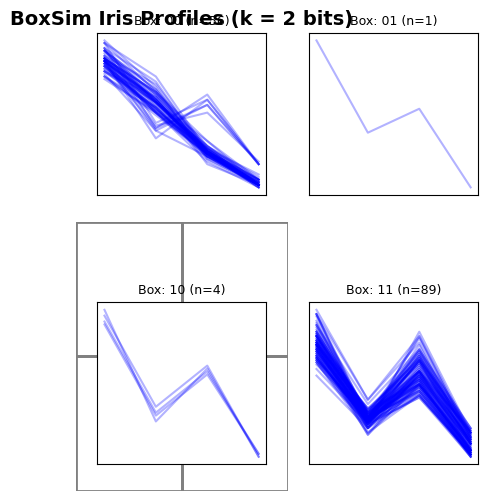

/tmp/ipykernel_15285/1336272201.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


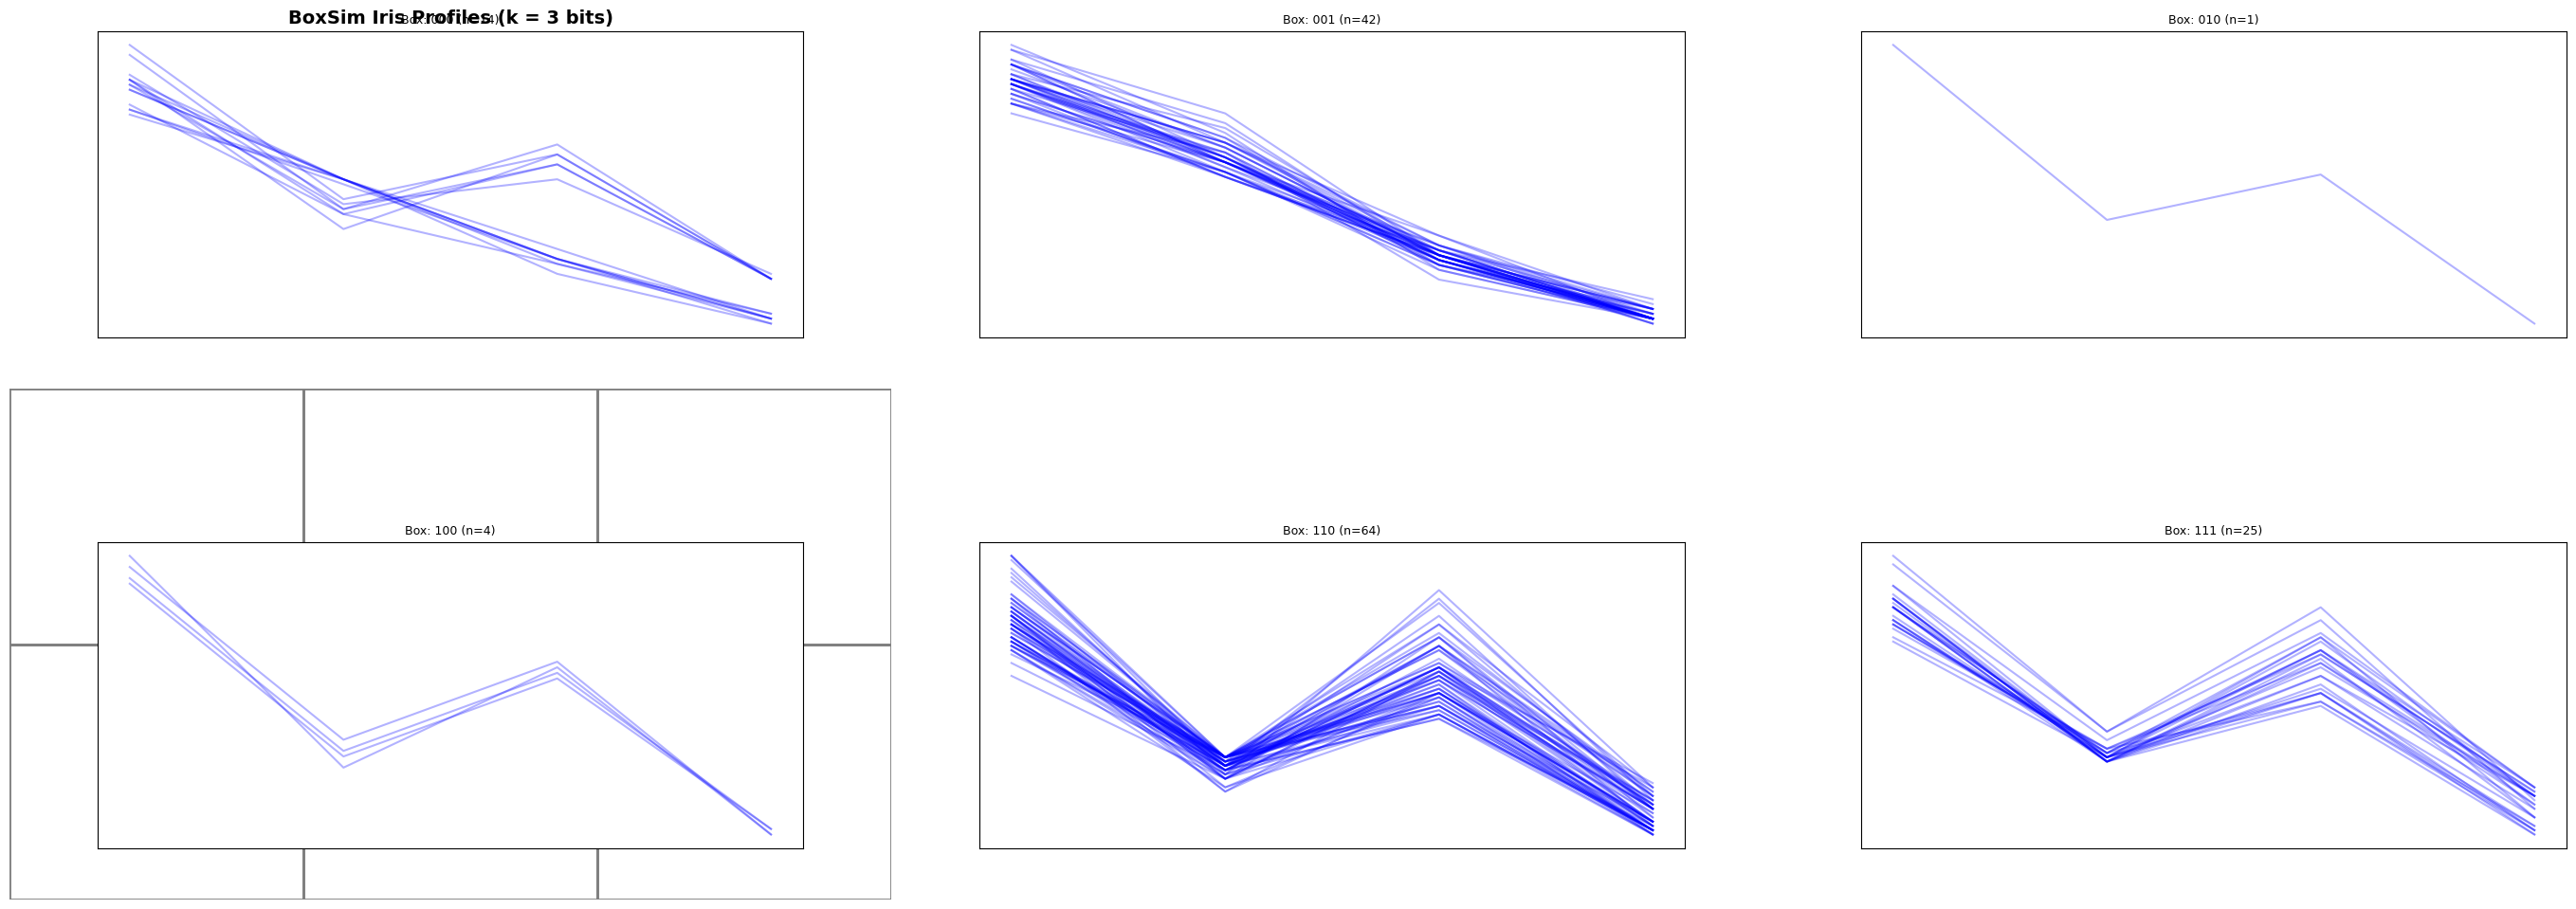

/tmp/ipykernel_15285/1336272201.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


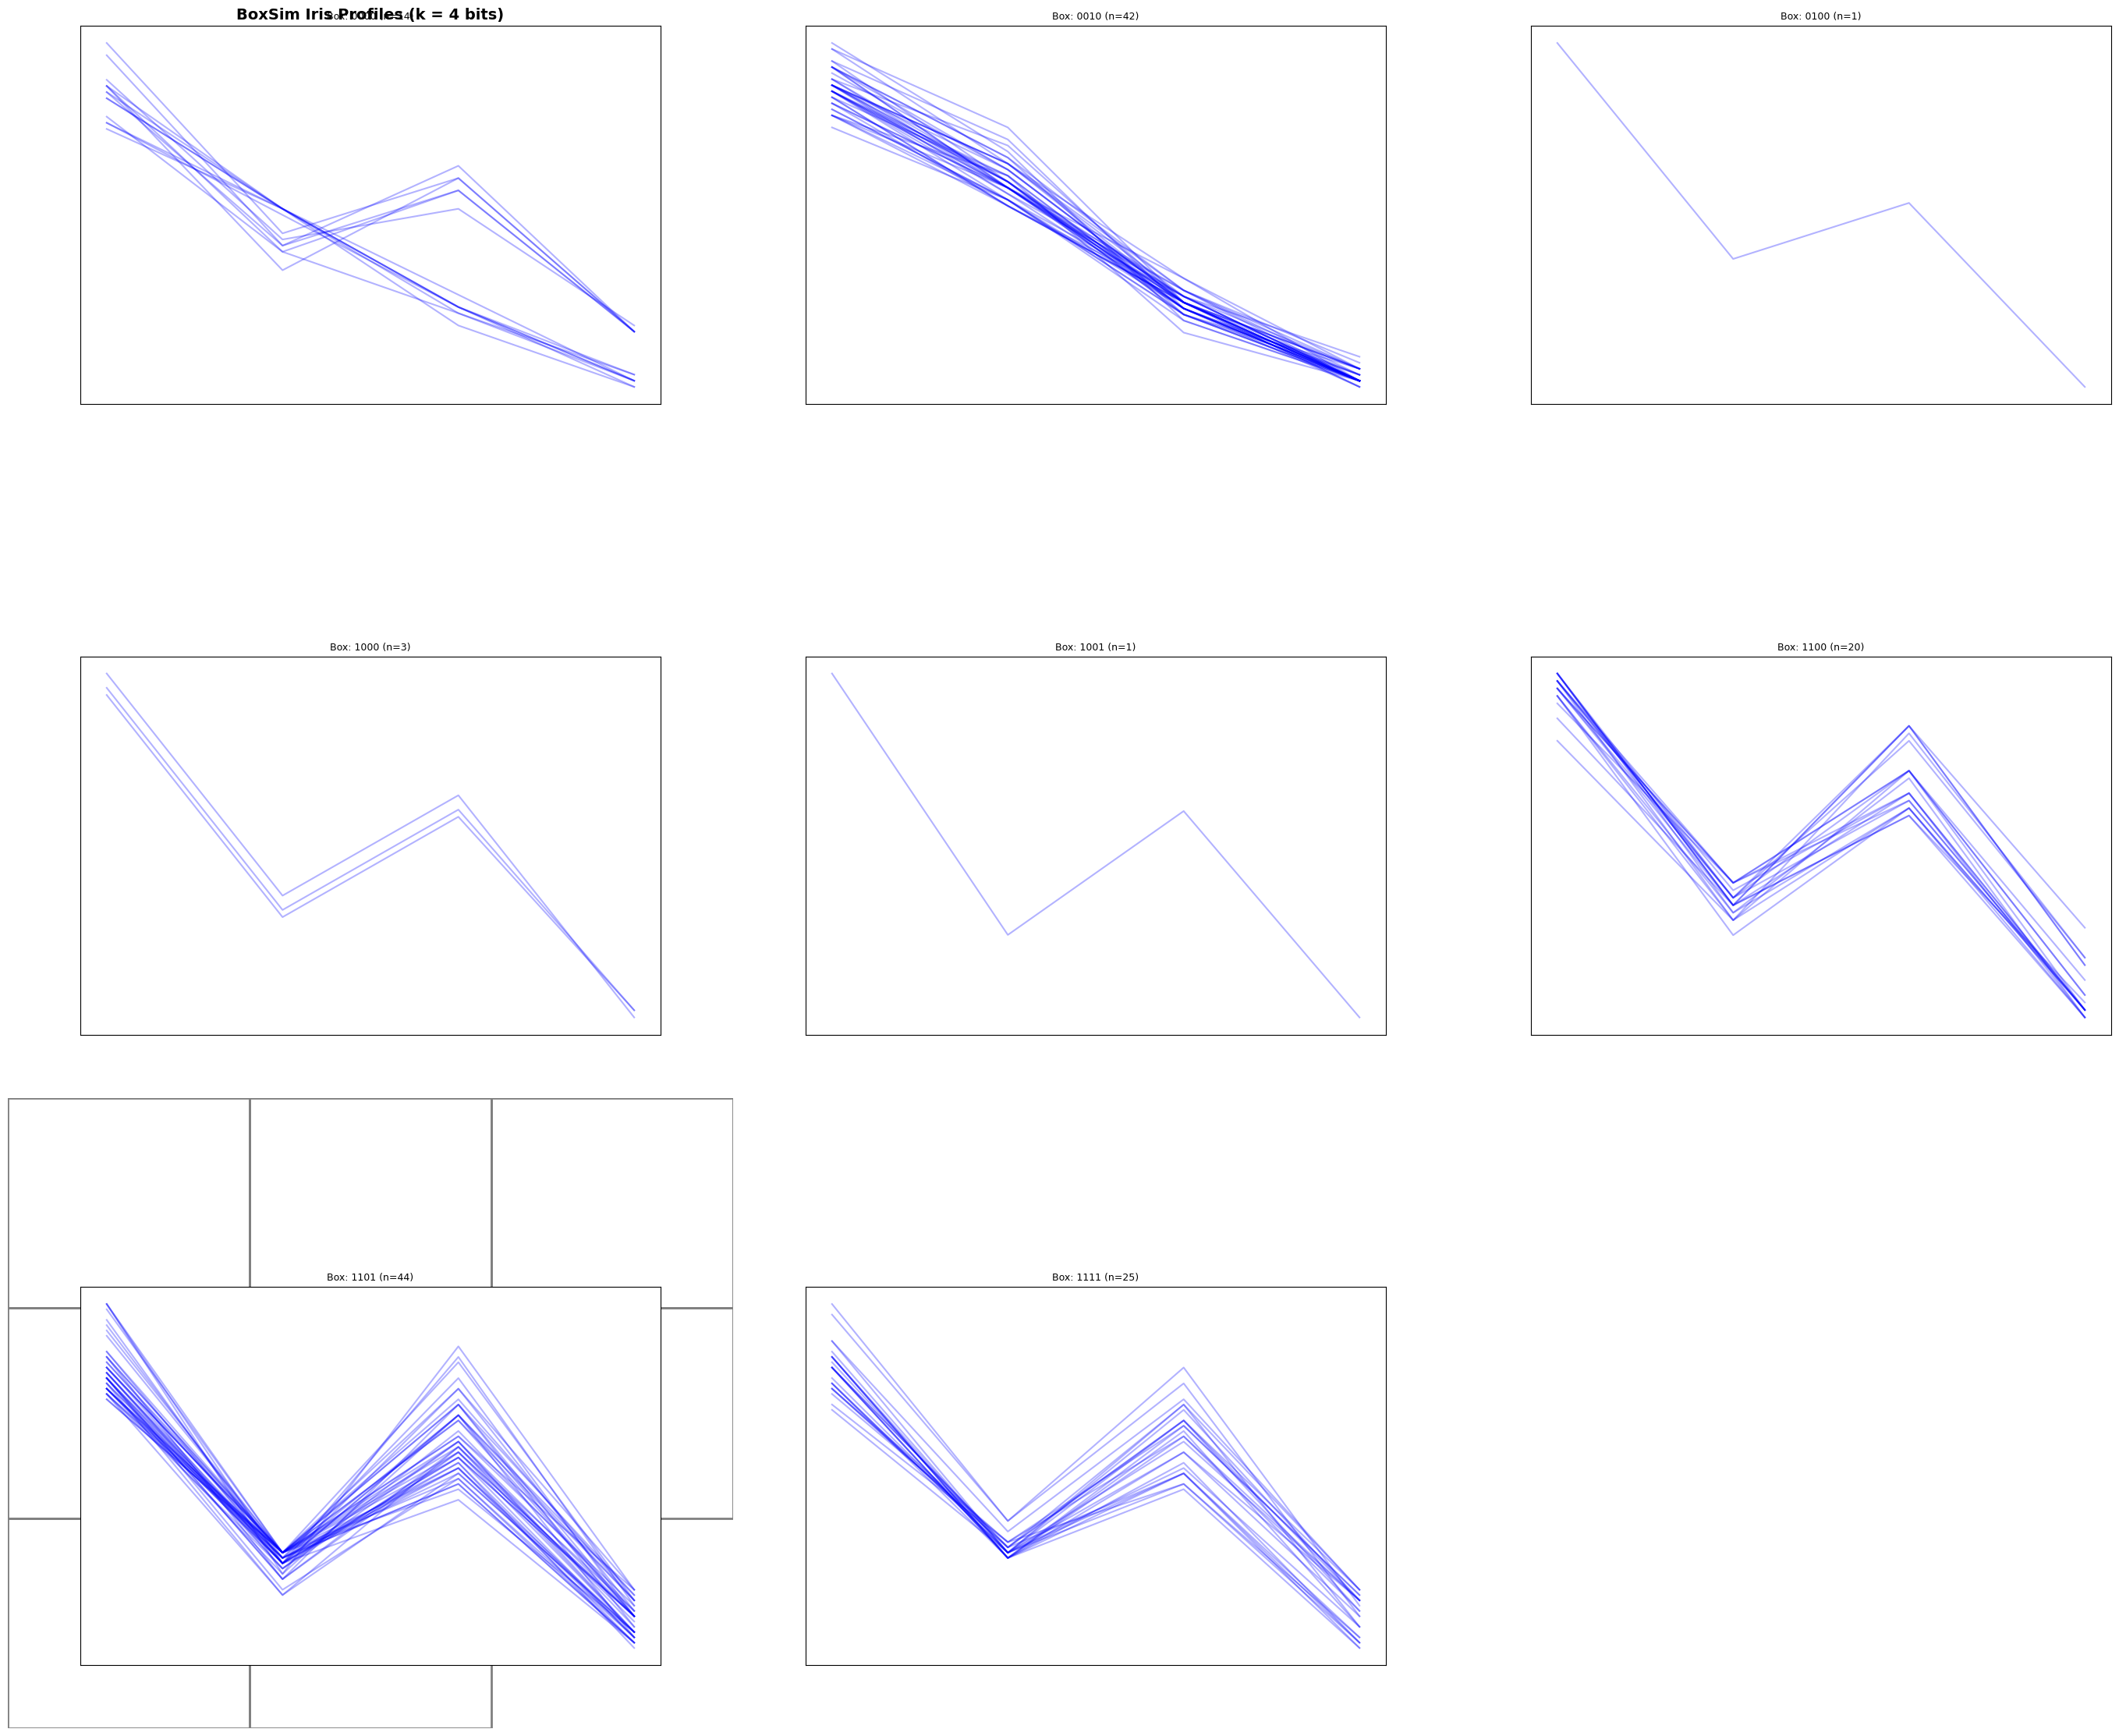

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import math
from sklearn.datasets import load_iris

# =========================================================
# 1) LOAD THE SAMPLE DATASET (IRIS)
# =========================================================
iris = load_iris()
df = pd.DataFrame(iris.data, columns=["Dim1", "Dim2", "Dim3", "Dim4"])
df.insert(0, "Index", np.arange(len(df)))

# =========================================================
# 2) EXTRACT ONLY THE NUMERIC VECTOR VALUES
# =========================================================
X = df[["Dim1", "Dim2", "Dim3", "Dim4"]].values

# =========================================================
# 3) NORMALIZE EACH VECTOR
# =========================================================
# NOTE: For Iris, we subtract the mean first so the >0 rule works,
# otherwise all Iris values (which are positive) would be Bit=1.
X_centered = X - np.mean(X, axis=0)
norms = np.linalg.norm(X_centered, axis=1, keepdims=True)
X_normalized = np.divide(X_centered, norms, where=(norms != 0))

# =========================================================
# 4) CONVERT EACH VECTOR INTO A BINARY VECTOR
# =========================================================
X_binary = (X_normalized > 0).astype(int)

# =========================================================
# 5) BUILD A BINARY DATAFRAME
# =========================================================
binary_df = pd.DataFrame(X_binary, columns=["Bit1", "Bit2", "Bit3", "Bit4"])
binary_df.insert(0, "Index", df["Index"])

# =========================================================
# 6) COMPUTE VARIANCE OF EACH BIT COLUMN
# =========================================================
bit_matrix = binary_df[["Bit1", "Bit2", "Bit3", "Bit4"]].values
column_variances = np.var(bit_matrix, axis=0)

usefulness_df = pd.DataFrame({
    "Column": ["Bit1", "Bit2", "Bit3", "Bit4"],
    "Variance": column_variances
}).sort_values(by="Variance", ascending=True).reset_index(drop=True)

# =========================================================
# 7) REORDER COLUMNS BY USEFULNESS
# =========================================================
sorted_bit_columns = usefulness_df["Column"].tolist()
reordered_binary_df = binary_df[["Index"] + sorted_bit_columns].copy()

# =========================================================
# 8) SORT ROWS USING THE REORDERED BIT COLUMNS
# =========================================================
sorted_rows_df = reordered_binary_df.sort_values(by=sorted_bit_columns).reset_index(drop=True)
sorted_rows_df["BinaryCode"] = sorted_rows_df[sorted_bit_columns].astype(str).agg("".join, axis=1)

# =========================================================
# 9) FUNCTION TO FORM BOXES (YOUR ORIGINAL)
# =========================================================
def make_boxes(sorted_df, bit_cols, k):
    first_k_cols = bit_cols[:k]
    grouped_df = sorted_df.copy()
    grouped_df["Box"] = grouped_df[first_k_cols].astype(str).agg("".join, axis=1)
    box_summary = grouped_df.groupby("Box")["Index"].apply(list).reset_index(name="Members")
    box_summary["Count"] = box_summary["Members"].apply(len)
    return grouped_df, box_summary

# =========================================================
# 10) CREATIVE GRID VISUALIZATION (UPDATED)
# =========================================================
def draw_box_grid_creative(box_summary, k, original_vectors):
    num_boxes = len(box_summary)
    cols = math.ceil(math.sqrt(num_boxes))
    rows = math.ceil(num_boxes / cols)

    fig, ax = plt.subplots(figsize=(cols * 4, rows * 3.5))
    ax.set_xlim(0, cols); ax.set_ylim(0, rows); ax.axis("off")
    ax.set_title(f"BoxSim Iris Profiles (k = {k} bits)", fontsize=14, fontweight="bold")

    for i, row in box_summary.iterrows():
        grid_row, grid_col = divmod(i, cols)
        x, y = grid_col, rows - grid_row - 1

        # Draw box
        ax.add_patch(Rectangle((x, y), 1, 1, fill=False, linewidth=2, color='gray'))

        # CREATIVE PART: Inset plot of vector shapes
        # We put a mini-plot inside the rectangle area
        inset = ax.inset_axes([x + 0.1, y + 0.1, 0.8, 0.6])
        members = row["Members"]

        # Plot each vector in the box as a line
        for m_idx in members:
            inset.plot(original_vectors[m_idx], alpha=0.3, color='blue')

        inset.set_xticks([]); inset.set_yticks([])
        inset.set_title(f"Box: {row['Box']} (n={row['Count']})", fontsize=9)

    plt.tight_layout()
    plt.show()

# =========================================================
# 11) RUN FOR K = 2, 3, 4
# =========================================================
for k in range(2, 5):
    grouped_rows, box_summary = make_boxes(sorted_rows_df, sorted_bit_columns, k)
    draw_box_grid_creative(box_summary, k, X)

1. What the Lines Represent

Each line represents a single Iris flower (a row from your dataset).

The x-axis of the mini-plot shows the 4 dimensions: Sepal Length, Sepal Width, Petal Length, and Petal Width.

The y-axis represents the actual measurement (in cm) for that specific dimension.

By plotting multiple lines in one box, you can see the "Physical Profile" of that cluster. If the lines are tightly bundled together, it means your binary hashing successfully grouped flowers with nearly identical physical shapes.

Generating Symbolic Grid for k = 2...


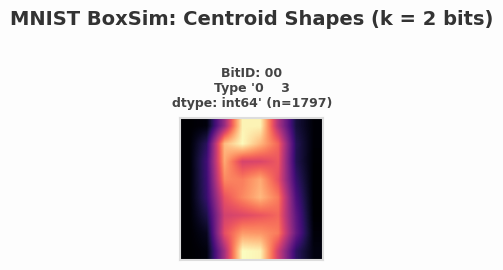

Generating Symbolic Grid for k = 4...


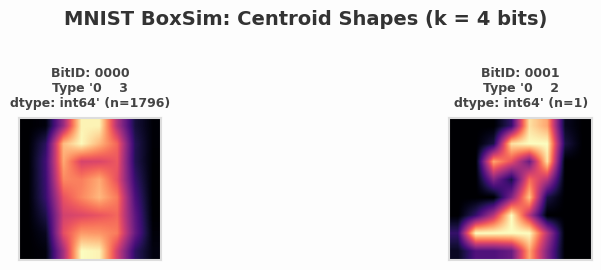

Generating Symbolic Grid for k = 6...


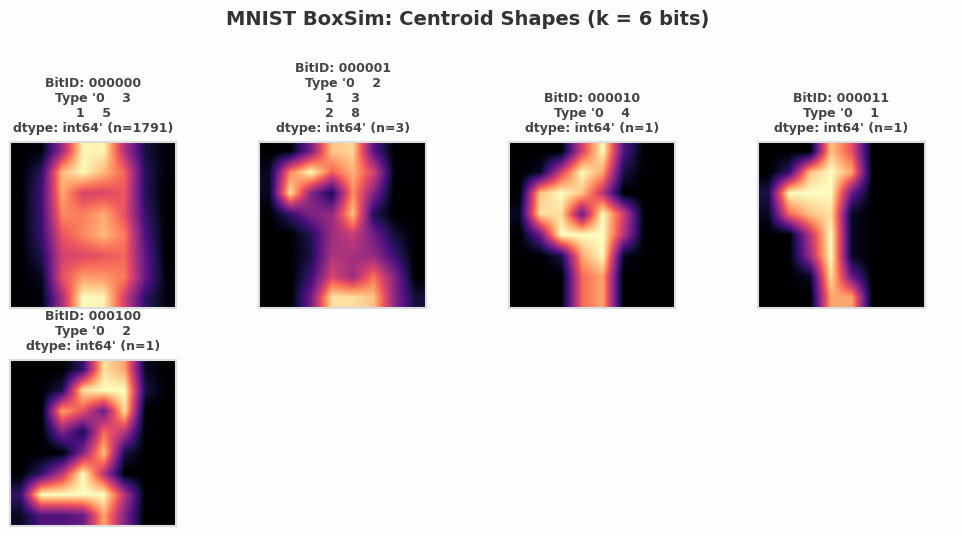

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import math
from sklearn.datasets import load_digits

# =========================================================
# 1) LOAD THE SAMPLE DATASET (MNIST/Digits)
# =========================================================
digits = load_digits()
df = pd.DataFrame(digits.data, columns=[f"Dim{i}" for i in range(64)])
df.insert(0, "Index", np.arange(len(df)))
y_labels = digits.target

# =========================================================
# 2-8) YOUR EXACT ALGORITHM LOGIC (NO CHANGES)
# =========================================================
X = df.drop("Index", axis=1).values
X_centered = X - np.mean(X, axis=0)
norms = np.linalg.norm(X_centered, axis=1, keepdims=True)
norms[norms == 0] = 1
X_normalized = X_centered / norms
X_binary = (X_normalized > 0).astype(int)

binary_df = pd.DataFrame(X_binary, columns=df.columns[1:])
binary_df.insert(0, "Index", df["Index"])

bit_matrix = binary_df.drop("Index", axis=1).values
column_variances = np.var(bit_matrix, axis=0)

usefulness_df = pd.DataFrame({
    "Column": df.columns[1:],
    "Variance": column_variances
}).sort_values(by="Variance", ascending=True).reset_index(drop=True)

sorted_bit_columns = usefulness_df["Column"].tolist()
reordered_binary_df = binary_df[["Index"] + sorted_bit_columns].copy()
sorted_rows_df = reordered_binary_df.sort_values(by=sorted_bit_columns).reset_index(drop=True)

def make_boxes(sorted_df, bit_cols, k):
    first_k_cols = bit_cols[:k]
    grouped_df = sorted_df.copy()
    grouped_df["Box"] = grouped_df[first_k_cols].astype(str).agg("".join, axis=1)
    box_summary = (
        grouped_df.groupby("Box")["Index"]
        .apply(list)
        .reset_index(name="Members")
    )
    box_summary["Count"] = box_summary["Members"].apply(len)
    return grouped_df, box_summary

# =========================================================
# 10) NEAT SYMBOLIC VISUALIZATION
# =========================================================
def draw_symbolic_grid(box_summary, k, original_vectors, true_labels):
    # Display top 16 boxes, or fewer if less exist
    display_summary = box_summary.sort_values(by="Count", ascending=False).head(16)
    num_boxes = len(display_summary)

    # Grid Layout logic: aim for 4 columns
    cols = min(4, num_boxes)
    rows = math.ceil(num_boxes / cols)

    # Set figsize dynamically: height scales with rows
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 2.8))
    fig.patch.set_facecolor('#fdfdfd') # Clean light background

    plt.suptitle(f"MNIST BoxSim: Centroid Shapes (k = {k} bits)",
                 fontsize=14, fontweight="bold", y=0.98, color='#333333')

    # Handle single row/single column cases for axes array
    if num_boxes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i, (idx, row) in enumerate(display_summary.iterrows()):
        ax = axes_flat[i]
        members = row["Members"]

        # Calculate Centroid
        centroid_image = np.mean(original_vectors[members], axis=0).reshape(8, 8)

        # Determine Dominant Digit (Fixing the .mode() output to get just the value)
        mode_val = pd.Series(true_labels[members]).mode()
        dominant_digit = mode_val if not mode_val.empty else "?"

        # Plot Image
        ax.imshow(centroid_image, cmap='magma', interpolation='bilinear')

        # Title Formatting: Multi-line for neatness
        title_str = f"BitID: {row['Box']}\nType '{dominant_digit}' (n={row['Count']})"
        ax.set_title(title_str, fontsize=9, fontweight='semibold', color='#444444', pad=8)

        # Removing ticks and styling borders
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#dddddd')
            spine.set_linewidth(1.5)

    # Hide unused grid slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    # Adjust layout to prevent title overlap
    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0, w_pad=2.0)
    plt.show()

# =========================================================
# 11) RUN EXPERIMENT
# =========================================================
k_values = [2, 4, 6]
for k_val in k_values:
    print(f"Generating Symbolic Grid for k = {k_val}...")
    _, summary = make_boxes(sorted_rows_df, sorted_bit_columns, k_val)
    draw_symbolic_grid(summary, k_val, X, y_labels)

/tmp/ipykernel_15285/2115730197.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')



Processing k = 2


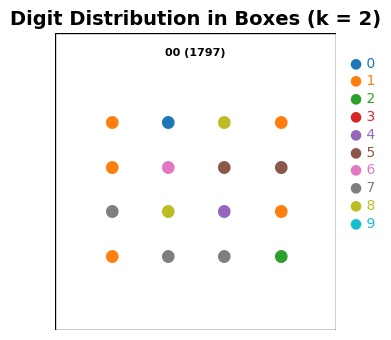


Processing k = 4


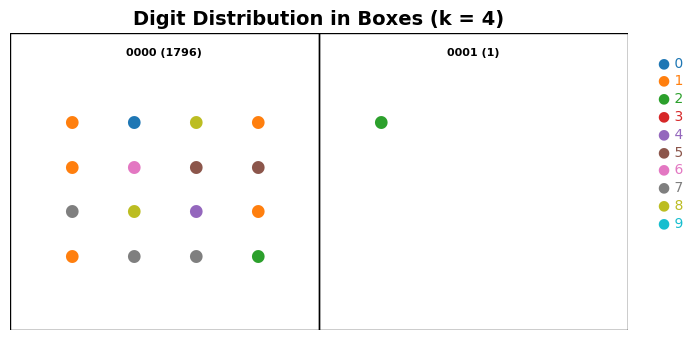


Processing k = 6


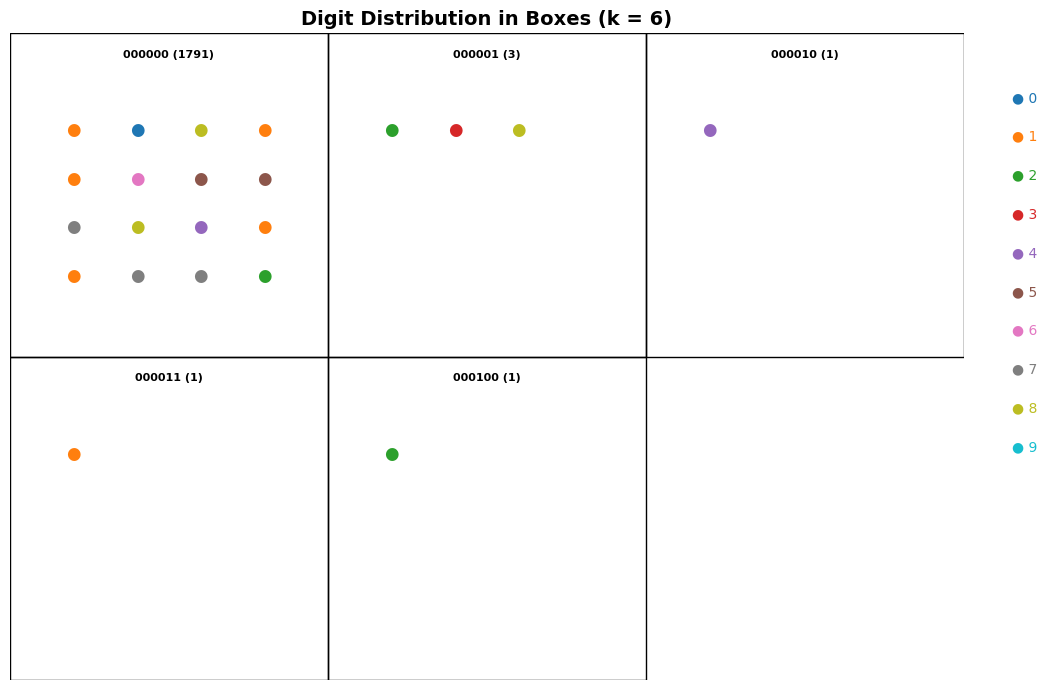


Processing k = 8


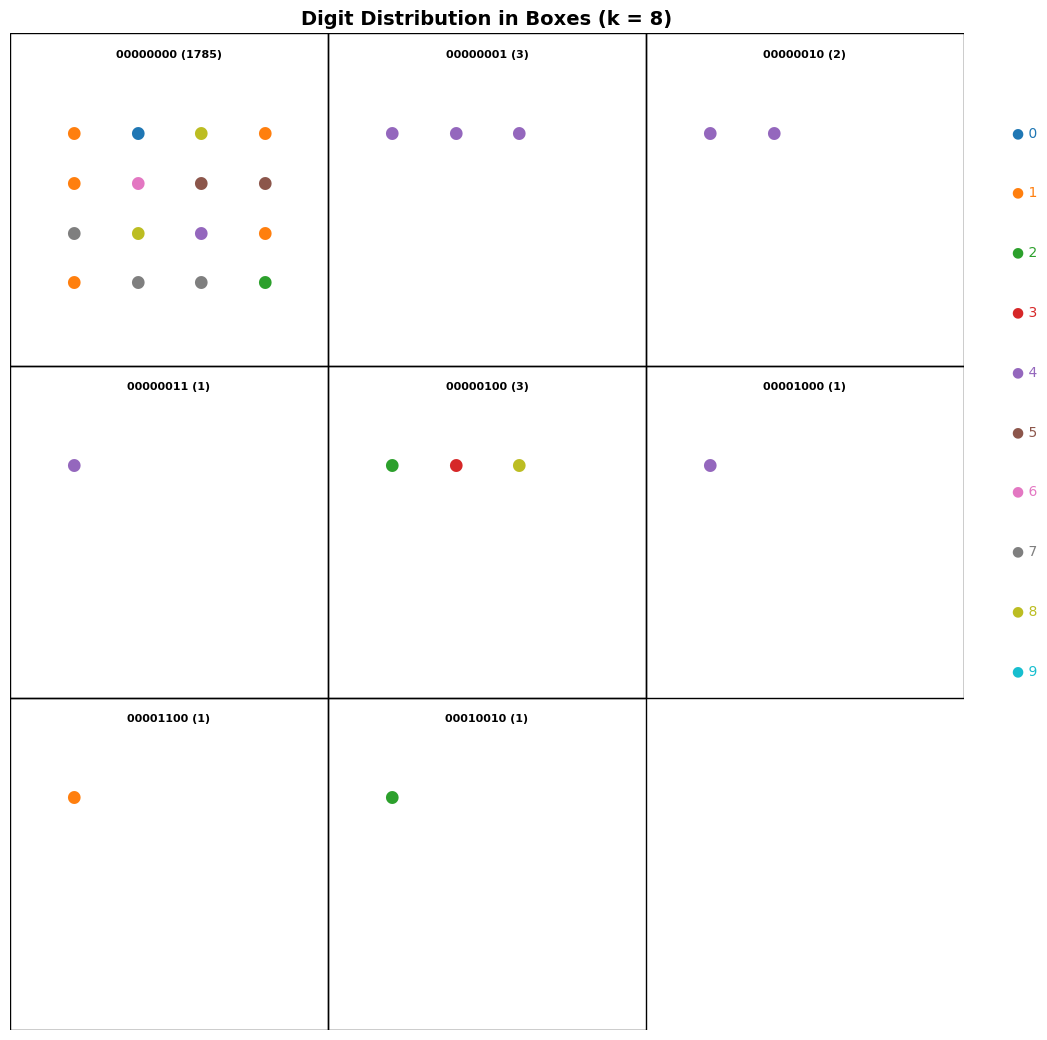

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import math
from sklearn.datasets import load_digits

# =========================================================
# 1) LOAD DATA
# =========================================================
digits = load_digits()

df = pd.DataFrame(digits.data, columns=[f"Dim{i}" for i in range(64)])
df.insert(0, "Index", np.arange(len(df)))

labels = digits.target
X = df.drop("Index", axis=1).values

# =========================================================
# 2) NORMALIZE
# =========================================================
X_centered = X - np.mean(X, axis=0)

norms = np.linalg.norm(X_centered, axis=1, keepdims=True)
norms[norms == 0] = 1

X_normalized = X_centered / norms

# =========================================================
# 3) BINARIZE
# =========================================================
X_binary = (X_normalized > 0).astype(int)

binary_df = pd.DataFrame(X_binary, columns=df.columns[1:])
binary_df.insert(0, "Index", df["Index"])

# =========================================================
# 4) VARIANCE SORT
# =========================================================
variances = np.var(binary_df.drop("Index", axis=1).values, axis=0)

usefulness_df = pd.DataFrame({
    "Column": df.columns[1:],
    "Variance": variances
}).sort_values(by="Variance").reset_index(drop=True)

sorted_bit_columns = usefulness_df["Column"].tolist()

# =========================================================
# 5) SORT ROWS
# =========================================================
reordered_binary_df = binary_df[["Index"] + sorted_bit_columns]
sorted_rows_df = reordered_binary_df.sort_values(
    by=sorted_bit_columns
).reset_index(drop=True)

# =========================================================
# 6) BOX FUNCTION
# =========================================================
def make_boxes(sorted_df, bit_cols, k):
    first_k = bit_cols[:k]

    df_copy = sorted_df.copy()
    df_copy["Box"] = df_copy[first_k].astype(str).agg("".join, axis=1)

    box_summary = (
        df_copy.groupby("Box")["Index"]
        .apply(list)
        .reset_index(name="Members")
    )

    box_summary["Count"] = box_summary["Members"].apply(len)
    return box_summary.sort_values(by="Box").reset_index(drop=True)

# =========================================================
# 7) COLOR MAP (PROFESSIONAL)
# =========================================================
cmap = cm.get_cmap('tab10')
digit_colors = [cmap(i) for i in range(10)]

# =========================================================
# 8) LEGEND FUNCTION
# =========================================================
def add_digit_legend(ax):
    legend_x = 1.05
    legend_y = 0.9

    for i, color in enumerate(digit_colors):
        ax.text(
            legend_x,
            legend_y - i * 0.06,
            f"● {i}",
            color=color,
            fontsize=10,
            transform=ax.transAxes,
            va="center"
        )

# =========================================================
# 9) COLORED DOT VISUALIZATION
# =========================================================
def draw_color_dot_boxes(box_summary, k, labels):
    display_summary = box_summary.head(16)

    cols = math.ceil(math.sqrt(len(display_summary)))
    rows = math.ceil(len(display_summary) / cols)

    fig, ax = plt.subplots(figsize=(cols * 3.5, rows * 3.5))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.axis("off")

    ax.set_title(f"Digit Distribution in Boxes (k = {k})", fontsize=14, fontweight="bold")

    for i, row in display_summary.iterrows():
        r, c = divmod(i, cols)
        x, y = c, rows - r - 1

        ax.add_patch(Rectangle((x, y), 1, 1, fill=False))

        members = row["Members"]
        member_labels = labels[members]

        # show up to 16 points
        sample_labels = member_labels[:16]

        for idx, digit in enumerate(sample_labels):
            rr, cc = divmod(idx, 4)

            ax.text(
                x + 0.2 + cc * 0.2,
                y + 0.7 - rr * 0.15,
                "●",
                color=digit_colors[digit],
                fontsize=12,
                ha="center",
                va="center"
            )

        # Box label
        ax.text(
            x + 0.5,
            y + 0.95,
            f"{row['Box']} ({row['Count']})",
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold"
        )

    # Add legend
    add_digit_legend(ax)

    plt.tight_layout()
    plt.show()

# =========================================================
# 10) RUN
# =========================================================
k_values = [2, 4, 6, 8]

for k_val in k_values:
    print(f"\nProcessing k = {k_val}")
    box_summary = make_boxes(sorted_rows_df, sorted_bit_columns, k_val)

    draw_color_dot_boxes(box_summary, k_val, labels)